# Task 4: Prioritise Potential Drug Target Genes

## Objective
Using the perturbation results from Tasks 2 and 3, identify and rank
the top target genes that most effectively shift ALS cells toward a
healthy embedding state.

## Scoring Logic
A gene is a good drug target if perturbing it in ALS cells moves those
cells as close as possible to the healthy baseline embedding.

We combine two signals into a single **therapeutic score**:
- **Cosine shift** — how strongly the perturbation changes cell state
- **kNN distance to healthy** — how close the perturbed ALS cells get to healthy cells

### Score formula
```
```
therapeutic_score = cosine_shift / knn_dist_to_healthy

### Imports

In [2]:
import sys
sys.path.append("..")

import logging
logging.basicConfig(level=logging.INFO)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis import compute_shifts_both_metrics, compute_knn_overlap_adata

sc_settings = {"dpi": 120, "frameon": False}

### Load results 

In [3]:
# Load results 
results_all = dict(np.load("../outputs/task2/results_all_v2.npz", allow_pickle=True))
cells_all = pd.read_csv("../outputs/task2/adata_all_celltypes_v2.csv", index_col=0, header=0, names=["CellType"])
conditions_all = pd.read_csv("../outputs/task2/adata_all_conditions_v2.csv", index_col=0, header=0, names=["Condition"])

summary = pd.read_csv("../outputs/summary_table_task3.csv")
print(summary.head())
print(f"\nTotal conditions: {len(summary)}")

        Gene       Mode  Cosine shift ALS (×10⁻⁴)  Cosine shift PN (×10⁻⁴)  \
0     UBQLN2    knockup                      1.06                     0.85   
1  HNRNPA2B1  knockdown                      1.42                     0.92   
2       TBK1    knockup                      0.56                     0.45   
3    HNRNPA1  knockdown                      1.44                     1.19   
4        VCP    knockup                      0.79                     0.64   

   Selectivity  kNN dist to healthy  Overall rank  
0         1.25             0.044195          11.7  
1         1.54             0.044672          12.3  
2         1.24             0.043932          12.7  
3         1.21             0.044375          12.7  
4         1.23             0.044078          13.0  

Total conditions: 30


In [4]:
ranked = summary.sort_values("kNN dist to healthy", ascending=True).reset_index(drop=True)
ranked.index += 1
ranked.index.name = "Rank"

print("── Top drug targets: genes that most effectively rescue ALS state ──")
print(ranked[["Gene", "Mode", "kNN dist to healthy", "Selectivity", "Cosine shift ALS (×10⁻⁴)"]].to_string())
ranked.to_csv("../outputs/task4/drug_targets.csv")

── Top drug targets: genes that most effectively rescue ALS state ──
           Gene       Mode  kNN dist to healthy  Selectivity  Cosine shift ALS (×10⁻⁴)
Rank                                                                                  
1          TBK1    knockup             0.043932         1.24                      0.56
2          TBK1  knockdown             0.043980         1.15                      1.00
3       C9orf72    knockup             0.043993         1.15                      0.77
4           VCP    knockup             0.044078         1.23                      0.79
5          NEK1    knockup             0.044083         1.20                      0.48
6           ANG  knockdown             0.044084         1.13                      1.31
7           ANG    knockup             0.044084         1.13                      1.31
8       C9orf72  knockdown             0.044092         1.14                      1.11
9           VCP  knockdown             0.044143         1.20 

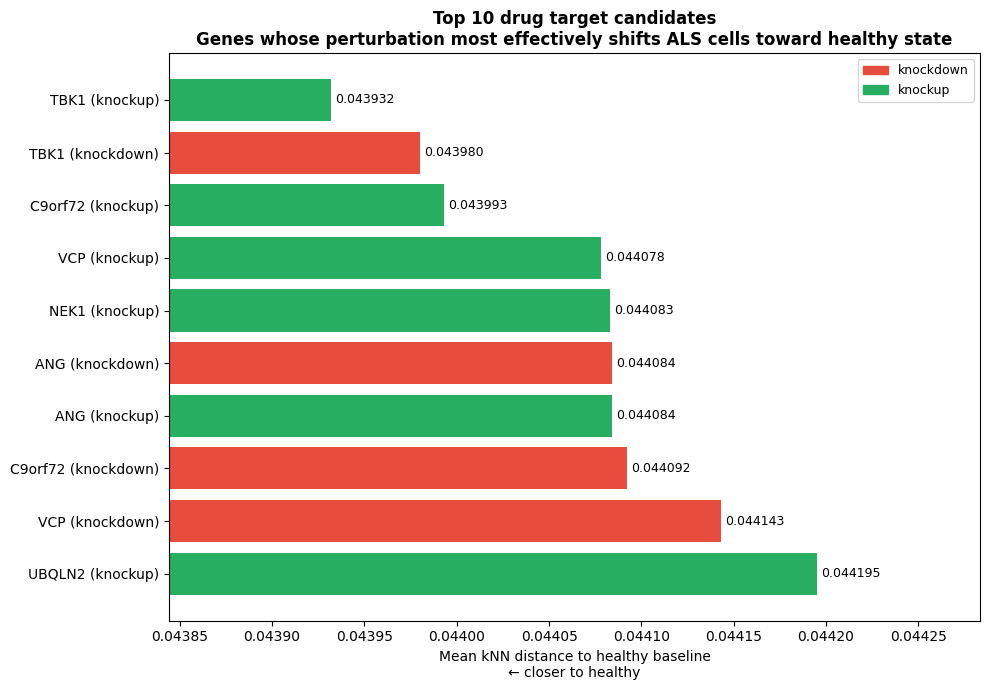

In [9]:
import matplotlib.patches as mpatches
# Cell 4
top10 = ranked.head(10).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#E74C3C" if m == "knockdown" else "#27AE60" for m in top10["Mode"]]
bars = ax.barh(top10["Gene"] + " (" + top10["Mode"] + ")",
               top10["kNN dist to healthy"], color=colors)

ax.set_xlim(top10["kNN dist to healthy"].min() * 0.998,
            top10["kNN dist to healthy"].max() * 1.002)

ax.bar_label(bars, fmt="%.6f", padding=3, fontsize=9)
ax.set_xlabel("Mean kNN distance to healthy baseline\n← closer to healthy")
ax.set_title("Top 10 drug target candidates\n"
             "Genes whose perturbation most effectively shifts ALS cells toward healthy state",
             fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color="#E74C3C", label="knockdown"),
    mpatches.Patch(color="#27AE60", label="knockup")
], fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("figures/task4/top_targets.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()



In [7]:
top1 = ranked.iloc[0]
print(f"\nTop candidate: {top1['Gene']} ({top1['Mode']})")
print(f"kNN distance to healthy: {top1['kNN dist to healthy']:.6f}")
print(f"Selectivity (ALS vs PN): {top1['Selectivity']:.2f}×")


Top candidate: TBK1 (knockup)
kNN distance to healthy: 0.043932
Selectivity (ALS vs PN): 1.24×
